In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
# even with a much more complicated data set let's manually create a kernel calculation

In [2]:
data = pd.read_csv("9-seismic_activity_svm.csv")

In [5]:
# Seismic Activity Classification
# underground_wave_energy -> Energy level of underground seismic wave (high variance)
# vibration_axis_variation -> Localized vibration variation on a vertical axis
# seismic_event_detected -> 1 = Seismic Event, 0 = No event (binary classification)

In [3]:
data

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0
...,...,...,...
395,-4.170824,-2.757576,1
396,-4.130115,-2.818182,1
397,-4.088102,-2.878788,1
398,-4.044745,-2.939394,1


In [6]:
data.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [8]:
data.isnull().sum()

underground_wave_energy     0
vibration_axis_variation    0
seismic_event_detected      0
dtype: int64

In [9]:
data["seismic_event_detected"].value_counts()

seismic_event_detected
0    200
1    200
Name: count, dtype: int64

<Axes: xlabel='underground_wave_energy', ylabel='vibration_axis_variation'>

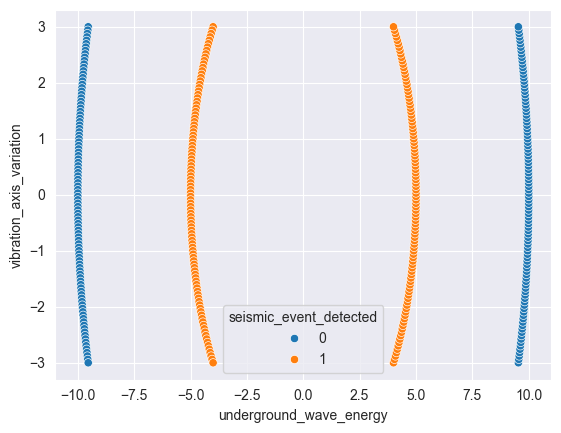

In [11]:
sns.scatterplot(x = data["underground_wave_energy"], y=data["vibration_axis_variation"], hue=data["seismic_event_detected"])

In [13]:
# manual rbf kernel

In [14]:
data.columns

Index(['underground_wave_energy', 'vibration_axis_variation',
       'seismic_event_detected'],
      dtype='object')

In [15]:
data["underground_wave_energy **2"] = data["underground_wave_energy"] **2
data["vibration_axis_variation **2"] = data["vibration_axis_variation"] **2
data["underground_wave_energy*vibration_axis_variation"] = (data["underground_wave_energy **2"]*data["vibration_axis_variation **2"])

In [16]:
data.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energy*vibration_axis_variation
0,9.539392,-3.000000,0,91.000000,9.000000,819.000000
1,9.558241,-2.939394,0,91.359963,8.640037,789.353438
2,9.576669,-2.878788,0,91.712580,8.287420,760.060641
3,9.594678,-2.818182,0,92.057851,7.942149,731.137149
4,9.612272,-2.757576,0,92.395776,7.604224,702.598182


In [17]:
X = data.drop("seismic_event_detected", axis=1)
y = data["seismic_event_detected"]

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.25, random_state=15)

In [20]:
X_train

,underground_wave_energy,vibration_axis_variation,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energy*vibration_axis_variation
383,-4.569231,-2.030303,20.877870,4.122130,86.061301
136,-9.966473,0.818182,99.330579,0.669421,66.494024
215,4.541817,-2.090909,20.628099,4.371901,90.184004
324,-4.755162,1.545455,22.611570,2.388430,54.006147
341,-4.973391,0.515152,24.734619,0.265381,6.564100
...,...,...,...,...,...
384,-4.541817,-2.090909,20.628099,4.371901,90.184004
375,-4.755162,-1.545455,22.611570,2.388430,54.006147
133,-9.949874,1.000000,99.000000,1.000000,99.000000
396,-4.130115,-2.818182,17.057851,7.942149,135.475992


In [24]:
data.columns

Index(['underground_wave_energy', 'vibration_axis_variation',
       'seismic_event_detected', 'underground_wave_energy **2',
       'vibration_axis_variation **2',
       'underground_wave_energy*vibration_axis_variation'],
      dtype='object')

In [23]:
import plotly.express as px

In [25]:
fig = px.scatter_3d(data, x='underground_wave_energy **2', y='vibration_axis_variation **2', z='underground_wave_energy*vibration_axis_variation', color ="seismic_event_detected")
fig.show()

In [26]:
from sklearn.svm import SVC

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
linear = SVC(kernel="linear")
linear.fit(X_train, y_train)
y_pred = linear.predict(X_test)

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       149
           1       1.00      1.00      1.00       151

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

[[149   0]
 [  0 151]]


In [29]:
# automatic rbf

In [30]:
data = pd.read_csv("9-seismic_activity_svm.csv")

In [31]:
X = data.drop("seismic_event_detected", axis=1)
y = data["seismic_event_detected"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.25, random_state=15)

In [35]:
# **2 dont use
linear = SVC(kernel="linear")
linear.fit(X_train, y_train)
y_pred2 = linear.predict(X_test)

print(classification_report(y_pred2, y_test))
print(confusion_matrix(y_pred2, y_test))

              precision    recall  f1-score   support

           0       0.50      0.49      0.49       152
           1       0.48      0.49      0.49       148

    accuracy                           0.49       300
   macro avg       0.49      0.49      0.49       300
weighted avg       0.49      0.49      0.49       300

[[74 78]
 [75 73]]


In [36]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred3 = rbf.predict(X_test)

print(classification_report(y_pred3, y_test))
print(confusion_matrix(y_pred3, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       149
           1       1.00      1.00      1.00       151

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

[[149   0]
 [  0 151]]
